In [2]:
import numpy as np
import pandas as pd
from prompt_toolkit.layout.utils import explode_text_fragments

df = pd.read_csv('./diyabet.csv')
df.head()


df.shape

df['Outcome'].value_counts()

x = df.drop('Outcome' , axis=1)

y = df['Outcome']

x = np.array(x)
y = np.array(y)

print(f"x = {x}")
print(f"y = {y}")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x = scaler.fit_transform(x)

print(f"x = {x}")

from sklearn.model_selection import train_test_split

x_train , x_test ,y_train ,y_test  = train_test_split(x , y ,test_size=0.1 , random_state=200)


x_train , y_train.shape

x_test , y_test.shape





from sklearn.naive_bayes import GaussianNB

base = GaussianNB(var_smoothing=1e-7)

base.fit(x_train , y_train)

y_pred_test = base.predict(x_test)


from sklearn.metrics import accuracy_score

acc_test = accuracy_score(y_test , y_pred_test)

print(acc_test)


x = [[  6.    148.     72.    ...  33.6     0.627  50.   ]
 [  1.     85.     66.    ...  26.6     0.351  31.   ]
 [  8.    183.     64.    ...  23.3     0.672  32.   ]
 ...
 [  5.    121.     72.    ...  26.2     0.245  30.   ]
 [  1.    126.     60.    ...  30.1     0.349  47.   ]
 [  1.     93.     70.    ...  30.4     0.315  23.   ]]
y = [1 0 1 0 1 0 1 0 1 1 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1 0 0 0 0 1 0 0 0 0 0
 1 1 1 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1
 1 0 0 1 1 1 0 0 0 1 0 0 0 1 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 1 0 1 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 1 0 1 0 1 0 0 0 0 0
 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 1
 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 1 1 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0
 1 0 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 0 1 1 1 0 0
 1 0 1 0 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 1 0 1 0 1 1 1

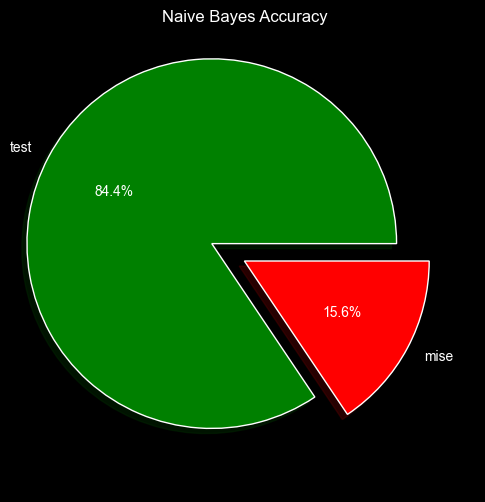

In [21]:
import matplotlib.pyplot as plt

correct = acc_test
incorrect = 1 - acc_test

plt.figure(figsize=(6,6))

plt.pie(
    [correct, incorrect],
    labels=['test', 'mise'],
    autopct='%1.1f%%',
    explode=(0.2, 0),
    shadow=True,
    colors = ["green" , "red"]
)

plt.title('Naive Bayes Accuracy')
plt.show()